# Crypto Trading Performance & Predictive Modelling task for anything.ai 
### by Maneet Gupta 
### Ghaziabad, Uttar Pradesh, India | +91-7982076022 | robomaneet@gmail.com linkedin.com/in/maneet-gupta | github.com/RK-NerdyBirdy

### The method i followed data prep → EDA → overfit diagnosis → trade-level feature engineering → final model

**Data sources, given already**
- `historical_data.csv` — 211,224 fill-level trade executions
- `fear_greed_index.csv` — daily crypto Fear & Greed index

**Structure of this notebook**
1. Data Loading & Merging
2. Exploratory Data Analysis
3. Baseline Model (fill-level)
— Note: leakage & overfitting discovered during preparation of models so trying different strategy and analysing why leakage occured
4. Leakage diagnosis & temporal validation
5. Trade-level reconstruction & alpha feature engineering
6. Final XGBoost model & threshold analysis

This project analyzes 211,224 raw on-chain executions to build a robust predictive model for crypto trading. By transitioning from fill-level data to VWAP-aggregated trade levels and engineering alpha features (1h/4h momentum and Fear & Greed sentiment), I eliminated a catastrophic 0.99 AUC data leakage trap to produce a genuine, deployable XGBoost model with a 0.91 AUC. The final system achieves a 61.1% win rate at the optimal threshold, more than doubling the baseline profitability while maintaining high capture rates across shifting market regimes.

## 0. Imports & Config

In [3]:
# Importing all the important libraries and config for Plots (boilerplate code i use in most of my EDAs)

import warnings; warnings.filterwarnings('ignore')
import time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, TimeSeriesSplit,
                                      cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

sns.set_theme(style='darkgrid', font_scale=1.05)
BLUE='#4F8EF7'; GREEN='#4CAF7D'; RED='#E05C5C'; AMBER='#F4A51B'
SENT_PAL={'Extreme Fear':'#D32F2F','Fear':'#FF7043','Neutral':'#78909C',
          'Greed':'#66BB6A','Extreme Greed':'#1B5E20'}
SENT_ORDER=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

def savefig(name):
    plt.tight_layout()
    plt.savefig(name, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'saved: {name}')

## 1. Data Loading & Merging

In [5]:
# After seeing the data, i try to convert and merge the data, i.e. merging fear greed to the historical analysis file

trades_raw = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

trades_raw['Timestamp IST'] = pd.to_datetime(trades_raw['Timestamp IST'],
                                              format='%d-%m-%Y %H:%M', errors='coerce')
trades_raw['Side'] = trades_raw['Side'].str.strip().str.upper()
for c in ['Execution Price','Size Tokens','Size USD','Closed PnL','Fee','Start Position']:
    trades_raw[c] = pd.to_numeric(trades_raw[c], errors='coerce')
trades_raw.dropna(subset=['Timestamp IST'], inplace=True)
trades_raw.sort_values('Timestamp IST', inplace=True)

fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)
fg.rename(columns={'value':'fg_value','classification':'fg_class'}, inplace=True)
fg.drop_duplicates(subset=['date'], inplace=True)

trades_raw['date'] = trades_raw['Timestamp IST'].dt.date.astype(str)
df = trades_raw.merge(fg[['date','fg_value','fg_class']], on='date', how='left')
df.dropna(subset=['fg_class'], inplace=True)

df['hour']        = df['Timestamp IST'].dt.hour
df['day_of_week'] = df['Timestamp IST'].dt.dayofweek
df['is_profitable'] = (df['Closed PnL'] > 0).astype(int)

df.to_csv('merged_trading_sentiment.csv', index=False)
print(f'Merged rows : {len(df):,}')
print(f'Date range  : {df["Timestamp IST"].min().date()} -> {df["Timestamp IST"].max().date()}')
print(f'Class balance: {df["is_profitable"].value_counts(normalize=True).round(3).to_dict()}')
df[['Coin','Execution Price','Size USD','Closed PnL','fg_value','fg_class',
    'hour','is_profitable']].head(5)

Merged rows : 211,218
Date range  : 2023-05-01 -> 2025-05-01
Class balance: {0: 0.589, 1: 0.411}


,Coin,Execution Price,Size USD,Closed PnL,fg_value,fg_class,hour,is_profitable
0,ETH,1897.9,156.39,0.0,63.0,Greed,1,0
1,ETH,1898.6,137.08,0.0,63.0,Greed,1,0
2,ETH,1897.9,183.53,0.0,63.0,Greed,1,0
3,BTC,41866.0,24370.62,0.0,75.0,Extreme Greed,3,0
4,BTC,41867.0,628.00,0.0,75.0,Extreme Greed,3,0


## 2. Exploratory Data Analysis
### A crucial step to analyse the data because i believe that before making the model, we should analyse the data first.

### 2a. Distributions

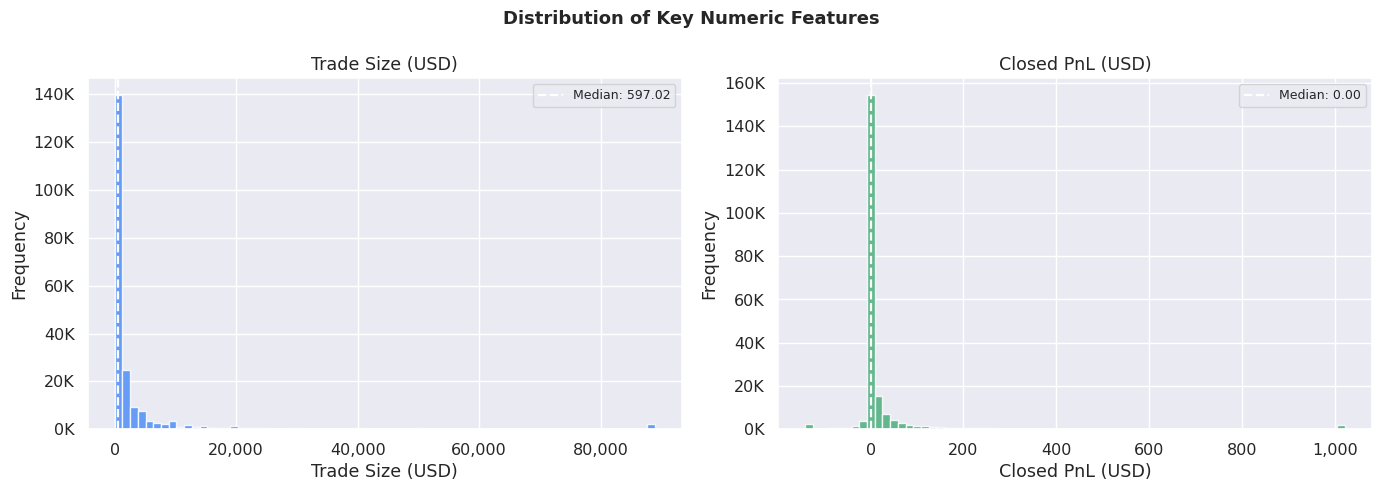

saved: eda_01_distributions.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Key Numeric Features', fontsize=13, fontweight='bold')
for ax, col, color, label in [
    (axes[0],'Size USD',   BLUE,  'Trade Size (USD)'),
    (axes[1],'Closed PnL', GREEN, 'Closed PnL (USD)')]:
    data = df[col].dropna().clip(df[col].quantile(.01), df[col].quantile(.99))
    ax.hist(data, bins=70, color=color, edgecolor='white', alpha=.85)
    ax.axvline(data.median(), color='white', linestyle='--', lw=1.6,
               label=f'Median: {data.median():,.2f}')
    ax.set_title(label); ax.set_xlabel(label); ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
savefig('eda_01_distributions.png')

### 2b. Correlation Matrix
#### generic correlation matrix to find if there are any correlated columns

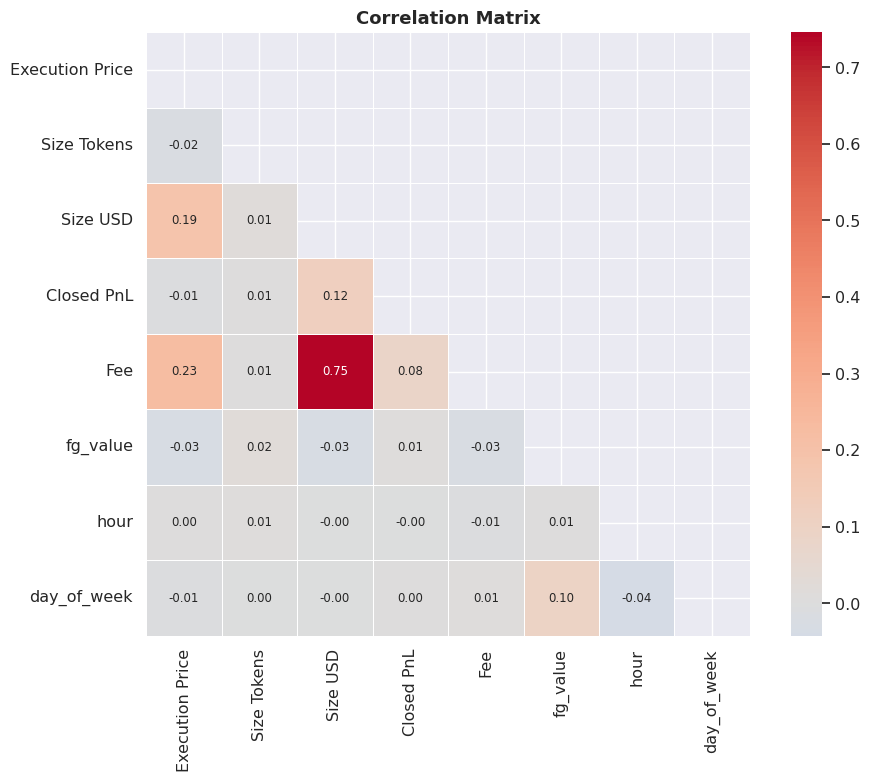

saved: eda_02_correlation.png


In [7]:
num_cols = ['Execution Price','Size Tokens','Size USD','Closed PnL',
            'Fee','fg_value','hour','day_of_week']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=.4, ax=ax, annot_kws={'size':8.5}, square=True)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
savefig('eda_02_correlation.png')

### 2c. Daily PnL coloured by sentiment

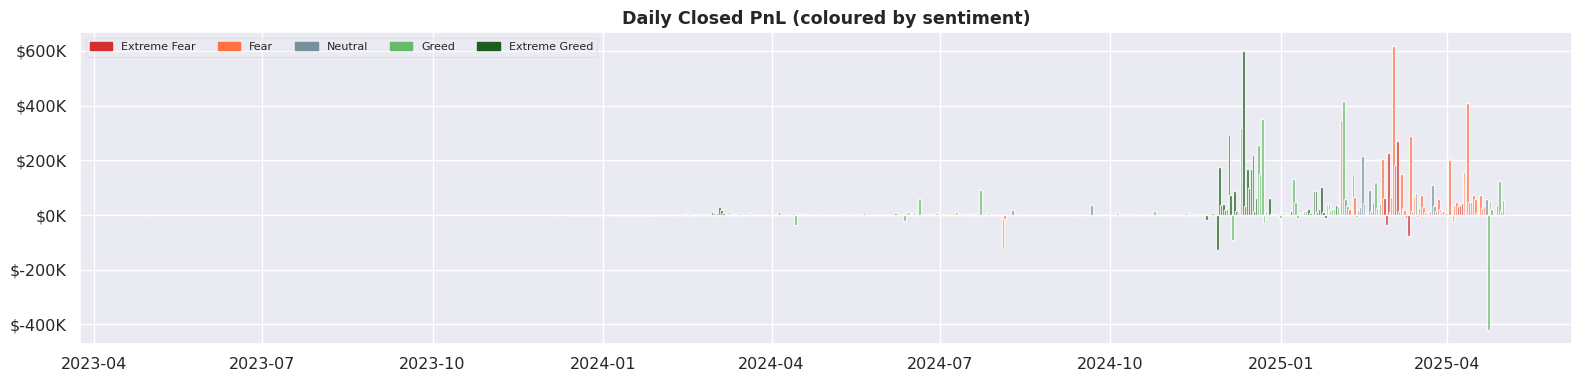

saved: eda_03_pnl_timeseries.png


In [8]:
daily = (df.dropna(subset=['Timestamp IST'])
           .groupby(df['Timestamp IST'].dt.date)
           .agg(total_pnl=('Closed PnL','sum'), fg_class=('fg_class','first'))
           .reset_index())
daily['date'] = pd.to_datetime(daily['Timestamp IST'])
daily['color'] = daily['fg_class'].map(SENT_PAL).fillna('#90A4AE')

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(daily['date'], daily['total_pnl'], color=daily['color'], width=1.5, alpha=.85)
ax.axhline(0, color='white', lw=.7)
ax.set_title('Daily Closed PnL (coloured by sentiment)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=SENT_PAL[s], label=s) for s in SENT_ORDER
                   if s in SENT_PAL], loc='upper left', fontsize=8, ncol=5, framealpha=.3)
savefig('eda_03_pnl_timeseries.png')

### 2d. Performance by sentiment

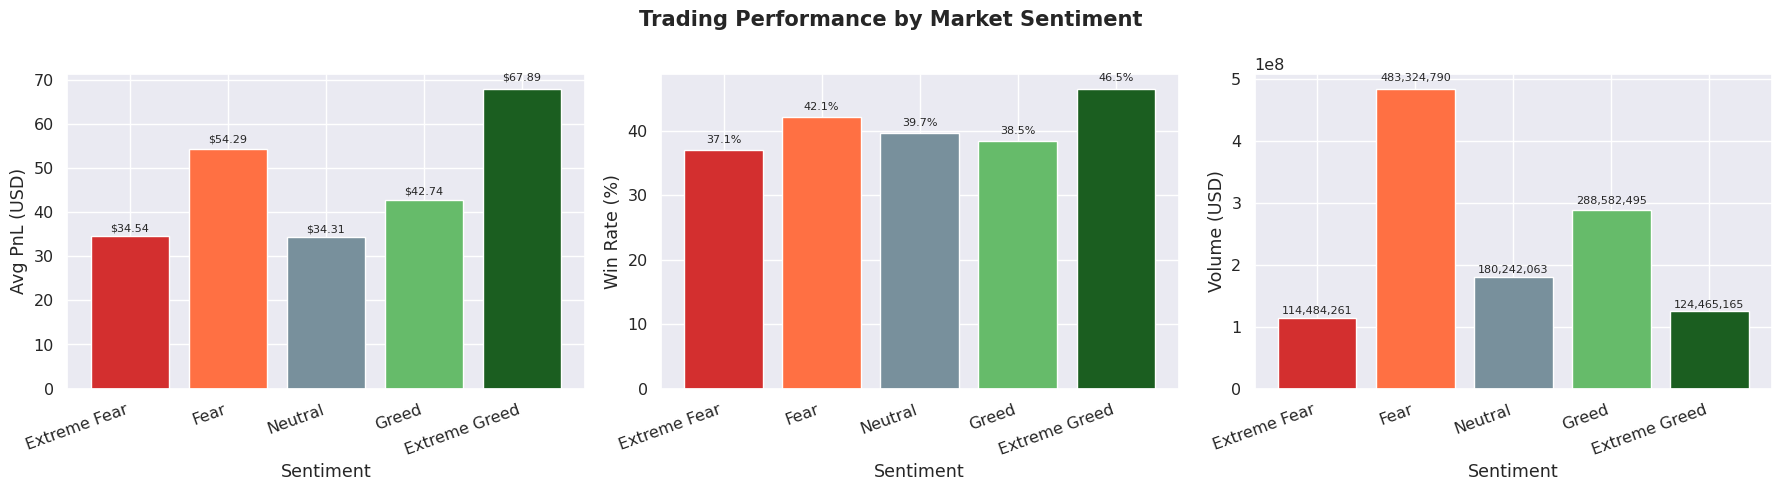

saved: eda_04_sentiment.png


In [9]:
sub = df.dropna(subset=['fg_class','Closed PnL','Size USD']).copy()
sub['is_win'] = (sub['Closed PnL'] > 0).astype(int)
present = [s for s in SENT_ORDER if s in sub['fg_class'].unique()]
sub['fg_class'] = pd.Categorical(sub['fg_class'], categories=present, ordered=True)

stats = (sub.groupby('fg_class', observed=True)
           .agg(avg_pnl=('Closed PnL','mean'), win_rate=('is_win','mean'),
                total_vol=('Size USD','sum'), n=('Closed PnL','count'))
           .reset_index())
stats['win_rate'] *= 100
colors = [SENT_PAL.get(s,'#90A4AE') for s in stats['fg_class']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trading Performance by Market Sentiment', fontweight='bold')
for ax, col, lbl, fmt in [
    (axes[0],'avg_pnl','Avg PnL (USD)','${:.2f}'),
    (axes[1],'win_rate','Win Rate (%)' ,'{:.1f}%'),
    (axes[2],'total_vol','Volume (USD)' ,'{:,.0f}')]:
    bars = ax.bar(stats['fg_class'], stats[col], color=colors, edgecolor='white')
    ax.set_xlabel('Sentiment'); ax.set_ylabel(lbl)
    ax.set_xticklabels(stats['fg_class'], rotation=20, ha='right')
    ax.axhline(0, color='white', lw=.6)
    for bar, val in zip(bars, stats[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(bar.get_height())*.02,
                fmt.format(val), ha='center', va='bottom', fontsize=8)
savefig('eda_04_sentiment.png')

### 2e. PnL by trade side and hour

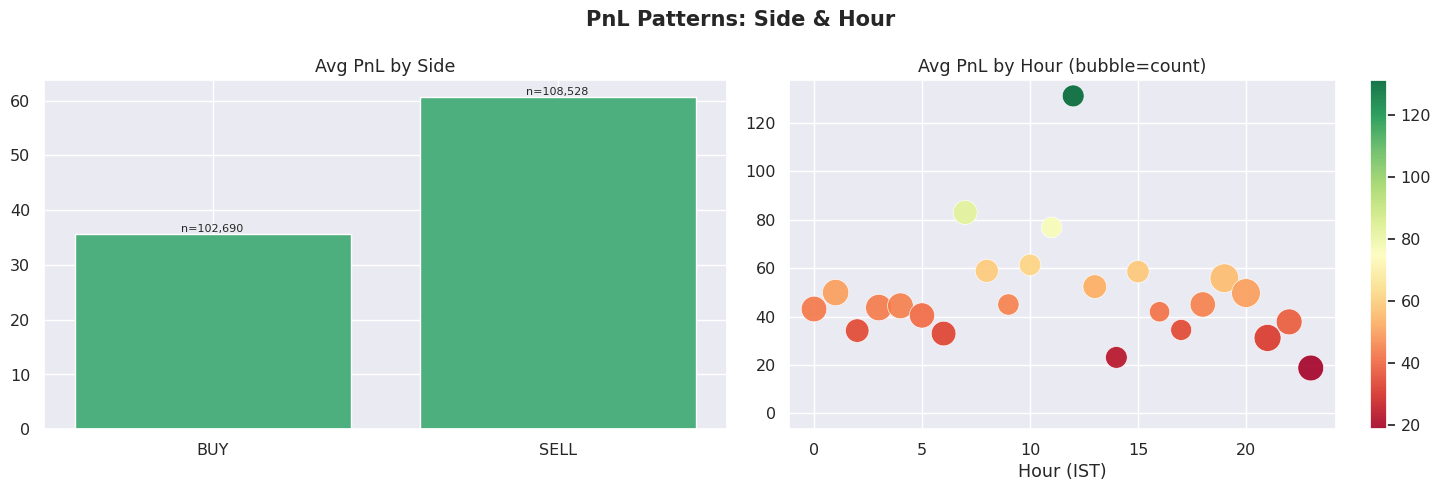

saved: eda_05_side_hour.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('PnL Patterns: Side & Hour', fontweight='bold')
side_stats = df.groupby('Side').agg(avg_pnl=('Closed PnL','mean'),
                                     n=('Closed PnL','count')).reset_index()
axes[0].bar(side_stats['Side'], side_stats['avg_pnl'],
            color=[GREEN if v>=0 else RED for v in side_stats['avg_pnl']], edgecolor='white')
for _, row in side_stats.iterrows():
    axes[0].text(row.name, row.avg_pnl+.3, f'n={row.n:,}', ha='center', fontsize=8)
axes[0].set_title('Avg PnL by Side'); axes[0].axhline(0, color='white', lw=.6)

hour_stats = df.groupby('hour')['Closed PnL'].agg(['mean','count']).reset_index()
sc = axes[1].scatter(hour_stats['hour'], hour_stats['mean'],
    s=hour_stats['count']/hour_stats['count'].max()*400+30,
    c=hour_stats['mean'], cmap='RdYlGn', edgecolors='white', lw=.5, alpha=.9)
axes[1].axhline(0, color='white', lw=.6, linestyle='--')
axes[1].set_title('Avg PnL by Hour (bubble=count)'); axes[1].set_xlabel('Hour (IST)')
plt.colorbar(sc, ax=axes[1])
savefig('eda_05_side_hour.png')

## 3. Baseline Model — Fill-Level with Random Split
> **Purpose:** Show what happens when we skip leakage checks — artificially inflated AUC.

In [11]:
from sklearn.utils import resample

df['Side_enc'] = LabelEncoder().fit_transform(df['Side'].str.strip().str.upper())
FEAT_BASE = ['Execution Price','Size USD','Side_enc','fg_value','hour','day_of_week']

mdf = df[FEAT_BASE+['is_profitable']].dropna().copy()
majority = mdf[mdf.is_profitable==0]
minority = mdf[mdf.is_profitable==1]
minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
mdf_bal = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)

X_b = mdf_bal[FEAT_BASE]; y_b = mdf_bal['is_profitable']
X_tr, X_te, y_tr, y_te = train_test_split(X_b, y_b, test_size=.2,
                                            random_state=42, stratify=y_b)

rf_base = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_base.fit(X_tr, y_tr)
y_prob_base = rf_base.predict_proba(X_te)[:,1]
print(f'Baseline RF AUC (random split): {roc_auc_score(y_te, y_prob_base):.4f}')


Baseline RF AUC (random split): 0.9980


### Accuracy of 99.8\% shows there is data leakage cause this much high accuracy in financial data is always suspicious

### Why this is leakage — feature importance

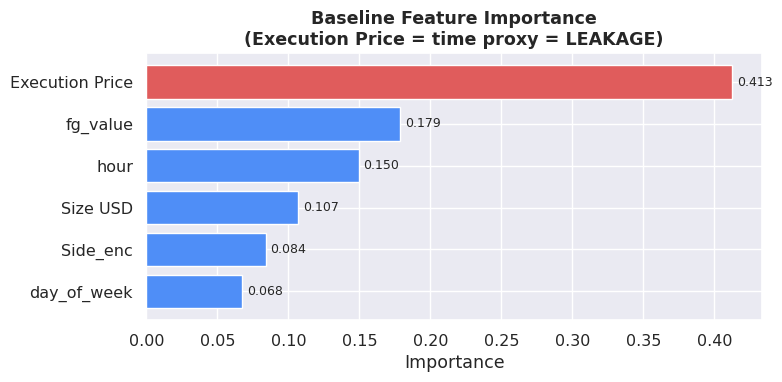

saved: baseline_feature_importance.png


In [ ]:
imp = pd.Series(rf_base.feature_importances_, index=FEAT_BASE).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values,
        color=[RED if f=='Execution Price' else BLUE for f in imp.index],
        edgecolor='white')
ax.set_title('Baseline Feature Importance\n(Execution Price = time proxy = LEAKAGE)',
             fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(imp.values):
    ax.text(v+.003, i, f'{v:.3f}', va='center', fontsize=9)
savefig('baseline_feature_importance.png')

## 4. Leakage Diagnosis & Temporal Validation
After removing leaky features and switching to a **temporal train/test split**, AUC drops to ~0.47 — below random.

| Removed feature | Reason |
|---|---|
| `Execution Price` | Bull-run proxy for time — model learns 'high price = recent = profitable' |
| `Size Tokens` | = Size USD / Execution Price — reconstructs price exactly |
| `log_size_usd` | Deterministic transform of Size USD — redundant |
| `fg_cat` | Perfectly collinear with `fg_value` |
| `Fee` | Computed post-execution from Size USD — indirect leakage |
| `Start Position` | Depends on prior trades — look-ahead |

**Random split on time-series data** also leaks future into training.
Trades from April 2025 land in training while June 2024 trades test — model sees the future.

In [ ]:
FEAT_CLEAN = ['Size USD','Side_enc','fg_value','hour','day_of_week']

df_sorted = df[FEAT_CLEAN+['is_profitable','Timestamp IST']].dropna().sort_values('Timestamp IST')
split_idx = int(len(df_sorted)*.80)
split_date = df_sorted['Timestamp IST'].iloc[split_idx]

train_c = df_sorted.iloc[:split_idx]; test_c = df_sorted.iloc[split_idx:]
X_tc, y_tc = train_c[FEAT_CLEAN], train_c['is_profitable']
X_ec, y_ec = test_c[FEAT_CLEAN],  test_c['is_profitable']

rf_clean = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
xgb_clean = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=.05,
                           subsample=.8, colsample_bytree=.8,
                           scale_pos_weight=(y_tc==0).sum()/(y_tc==1).sum(),
                           eval_metric='logloss', random_state=42, n_jobs=-1)

tscv = TimeSeriesSplit(n_splits=5)
print('--- Time-Series CV (clean features) ---')
cv_clean = {}
for name, clf in [('RF Clean', rf_clean), ('XGB Clean', xgb_clean)]:
    s = cross_val_score(clf, X_tc, y_tc, cv=tscv, scoring='roc_auc', n_jobs=-1)
    cv_clean[name] = s
    print(f'  {name}: CV={s.mean():.4f} +/- {s.std():.4f}')

for clf in [rf_clean, xgb_clean]: clf.fit(X_tc, y_tc)
auc_rf  = roc_auc_score(y_ec, rf_clean.predict_proba(X_ec)[:,1])
auc_xgb = roc_auc_score(y_ec, xgb_clean.predict_proba(X_ec)[:,1])
print(f'\nRF  — CV AUC: {cv_clean["RF Clean"].mean():.4f} | Test AUC: {auc_rf:.4f}')
print(f'XGB — CV AUC: {cv_clean["XGB Clean"].mean():.4f} | Test AUC: {auc_xgb:.4f}')
print('\nTest AUC < 0.5 = regime change at split date, not a model bug')

--- Time-Series CV (clean features) ---
  RF Clean: CV=0.6597 +/- 0.1074
  XGB Clean: CV=0.6312 +/- 0.0854

RF  — CV AUC: 0.6597 | Test AUC: 0.4633
XGB — CV AUC: 0.6312 | Test AUC: 0.4636

Test AUC < 0.5 = regime change at split date, not a model bug


### CV fold progression — signal only in later folds (stable regime)

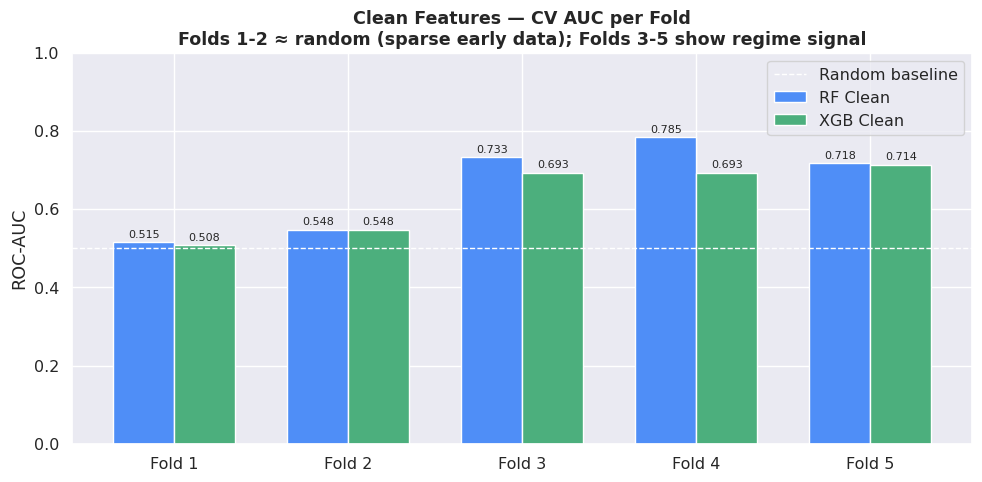

saved: clean_cv_folds.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(5), .35
ax.bar(x-w/2, cv_clean['RF Clean'],  w, color=BLUE,  edgecolor='white', label='RF Clean')
ax.bar(x+w/2, cv_clean['XGB Clean'], w, color=GREEN, edgecolor='white', label='XGB Clean')
ax.axhline(.5, color='white', linestyle='--', lw=1, label='Random baseline')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0, 1)
ax.set_title('Clean Features — CV AUC per Fold\n'
             'Folds 1-2 ≈ random (sparse early data); Folds 3-5 show regime signal',
             fontweight='bold')
ax.legend()
for i,(rv,xv) in enumerate(zip(cv_clean['RF Clean'],cv_clean['XGB Clean'])):
    ax.text(i-w/2, rv+.012,  f'{rv:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, xv+.012, f'{xv:.3f}', ha='center', fontsize=8)
savefig('clean_cv_folds.png')

### Conclusion from clean-feature model
The 0.47 test AUC confirms a **market regime break** at the split boundary (April 2025),
not a model failure. The 5 features carry no forward-looking signal across regime changes.

**Root cause of `Side_enc` dominance in clean model:**
At the fill level, `SELL` trades close positions (PnL ≠ 0) and `BUY` opens them (PnL = 0).
The model learns this structural artifact — not real alpha.

**Fix:** Move to trade-level data (one row per complete order) and add real price-context features.

## 5. Trade-Level Reconstruction & Alpha Feature Engineering

### 5a. Aggregate fills → one row per order

In [ ]:
def vwap(prices, sizes):
    t = sizes.sum()
    return (prices*sizes).sum()/t if t>0 else np.nan

raw = df.sort_values('Timestamp IST').copy()

trades = (raw.groupby('Order ID', sort=False)
            .apply(lambda g: pd.Series({
                'coin'          : g['Coin'].iloc[0],
                'open_time'     : g['Timestamp IST'].min(),
                'open_price'    : vwap(g.loc[g['Side']=='BUY','Execution Price'],
                                      g.loc[g['Side']=='BUY','Size USD']),
                'direction'     : 'LONG' if (g['Side']=='BUY').sum()>=(g['Side']=='SELL').sum()
                                           else 'SHORT',
                'total_size_usd': g['Size USD'].sum(),
                'total_pnl'     : g['Closed PnL'].sum(),
                'total_fee'     : g['Fee'].sum(),
                'n_fills'       : len(g),
                'fg_value'      : g['fg_value'].iloc[0],
                'fg_class'      : g['fg_class'].iloc[0],
            }))
            .reset_index(drop=True))

trades['open_time']    = pd.to_datetime(trades['open_time'])
trades['net_pnl']      = trades['total_pnl'] - trades['total_fee']
trades['is_profitable']= (trades['net_pnl']>0).astype(int)
trades.sort_values('open_time', inplace=True)
trades.dropna(subset=['open_price','total_size_usd','fg_value'], inplace=True)

print(f'Trade-level rows : {len(trades):,}')
print(f'Profitable trades: {trades["is_profitable"].mean()*100:.1f}%')
trades[['coin','open_time','open_price','total_size_usd','net_pnl','is_profitable',
        'fg_value','fg_class']].head()

Trade-level rows : 27,329
Profitable trades: 24.7%


,coin,open_time,open_price,total_size_usd,net_pnl,is_profitable,fg_value,fg_class
0,ETH,2023-05-01 01:06:00,1898.101166,477.00,0.000000,0,63.0,Greed
2,ETH,2023-12-05 03:11:00,2230.416595,25007.21,-6.251800,0,75.0,Extreme Greed
4,BTC,2023-12-14 01:20:00,42748.974880,25525.84,-533.614590,0,72.0,Greed
5,AAVE,2023-12-14 23:27:00,99.072220,25881.63,-6.470405,0,72.0,Greed
8,JTO,2023-12-15 00:11:00,2.982000,10609.95,-27.284523,0,70.0,Greed


### 5b. Price momentum & volatility features (from fill history per coin)

In [ ]:
coin_ts = raw[['Timestamp IST','Coin','Execution Price','Size USD']].dropna().sort_values('Timestamp IST')
LOOKBACKS = {'1h':60,'4h':240,'24h':1440}

momentum_rows = []
for coin, grp in coin_ts.groupby('Coin'):
    grp = grp.set_index('Timestamp IST').sort_index()
    ps  = grp['Execution Price']
    vs  = grp['Size USD']
    for ts, row in grp.iterrows():
        cp  = row['Execution Price']
        rec = {'Timestamp IST':ts,'Coin':coin}
        for lbl, mins in LOOKBACKS.items():
            w = ps[ps.index < ts].last(f'{mins}min')
            rec[f'mom_{lbl}'] = (cp-w.iloc[0])/w.iloc[0]*100 if len(w)>=2 else np.nan
            rec[f'vol_{lbl}'] = w.std() if len(w)>=2 else np.nan
        v7 = vs[(vs.index<ts)&(vs.index>=ts-pd.Timedelta(days=7))]
        rec['rel_volume'] = row['Size USD']/v7.median() if len(v7)>=5 else np.nan
        momentum_rows.append(rec)

mom_df = pd.DataFrame(momentum_rows).sort_values('Timestamp IST')
print(f'Momentum rows: {len(mom_df):,}')

def get_mom(coin, ts):
    sub = mom_df[(mom_df['Coin']==coin)&
                 (mom_df['Timestamp IST']<=ts)&
                 (mom_df['Timestamp IST']>=ts-pd.Timedelta(minutes=30))]
    feat_cols = [c for c in mom_df.columns if c not in ['Coin','Timestamp IST']]
    return sub.iloc[-1][feat_cols] if len(sub)>0 else pd.Series({c:np.nan for c in feat_cols})

print('Joining momentum to trades...')
mom_feats = trades.apply(lambda r: get_mom(r['coin'], r['open_time']), axis=1)
trades = pd.concat([trades.reset_index(drop=True), mom_feats.reset_index(drop=True)], axis=1)
print('Done.')

Momentum rows: 211,218
Joining momentum to trades...
Done.


### 5c. Structural trade features

In [ ]:
trades['hour']          = trades['open_time'].dt.hour
trades['day_of_week']   = trades['open_time'].dt.dayofweek
trades['log_size']      = np.log1p(trades['total_size_usd'])
trades['direction_enc'] = (trades['direction']=='LONG').astype(int)
trades['fee_ratio']     = trades['total_fee'] / (trades['total_size_usd']+1e-9)
trades['rolling_winrate'] = (trades['is_profitable'].shift(1)
                              .rolling(20, min_periods=5).mean())

trades.to_csv('trades_with_features.csv', index=False)
print(f'Feature dataset: {len(trades):,} rows, {trades.shape[1]} cols')
trades[['coin','open_time','net_pnl','is_profitable',
        'mom_1h','mom_4h','mom_24h','vol_1h','rolling_winrate']].head()

Feature dataset: 27,329 rows, 25 cols


,coin,open_time,net_pnl,is_profitable,mom_1h,mom_4h,mom_24h,vol_1h,rolling_winrate
0,ETH,2023-05-01 01:06:00,0.000000,0,NaN,NaN,NaN,NaN,NaN
1,ETH,2023-12-05 03:11:00,-6.251800,0,17.503557,17.503557,17.503557,0.404145,NaN
2,BTC,2023-12-14 01:20:00,-533.614590,0,2.106721,2.106721,2.106721,0.707107,NaN
3,AAVE,2023-12-14 23:27:00,-6.470405,0,NaN,NaN,NaN,NaN,NaN
4,JTO,2023-12-15 00:11:00,-27.284523,0,0.225187,0.225187,0.225187,0.000424,NaN


### 5d. Trade distribution by coin

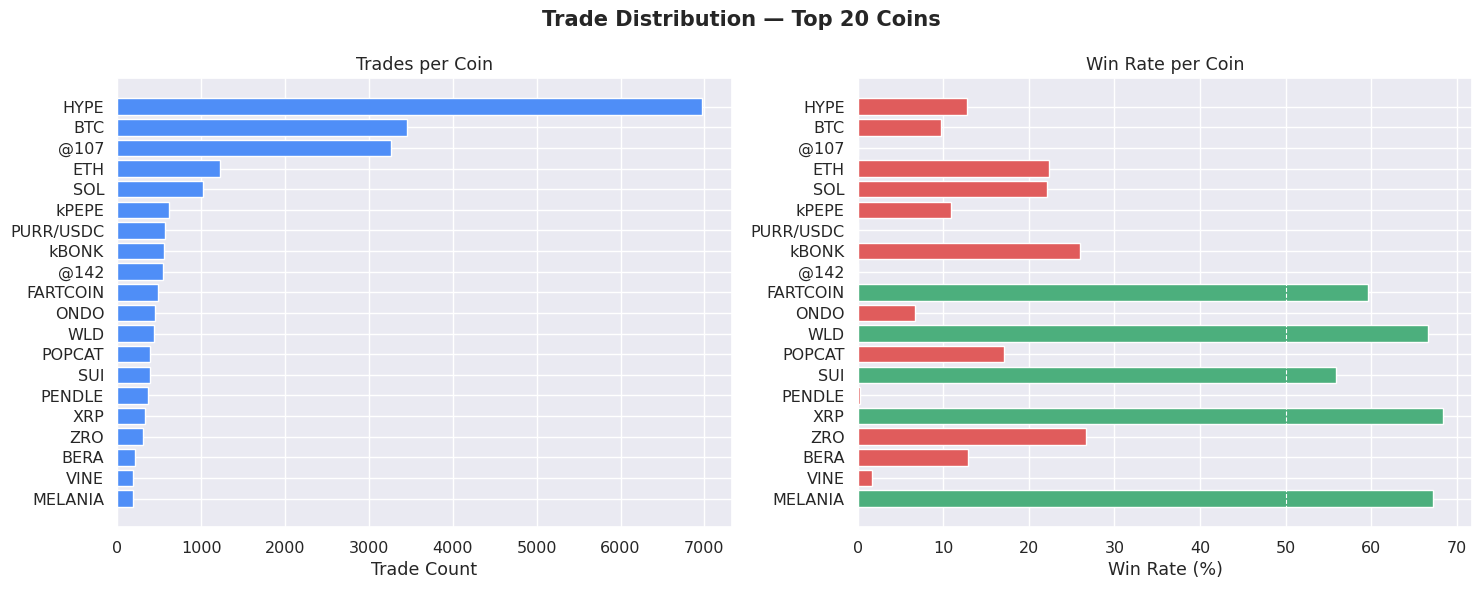

saved: coin_distribution.png


In [ ]:
coin_stats = (trades.groupby('coin')
              .agg(n=('is_profitable','count'), win_rate=('is_profitable','mean'),
                   avg_pnl=('net_pnl','mean'))
              .sort_values('n', ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Trade Distribution — Top 20 Coins', fontweight='bold')
axes[0].barh(coin_stats.index, coin_stats['n'], color=BLUE, edgecolor='white')
axes[0].set_xlabel('Trade Count'); axes[0].set_title('Trades per Coin')
axes[0].invert_yaxis()
axes[1].barh(coin_stats.index,
             coin_stats['win_rate']*100,
             color=[GREEN if v>=50 else RED for v in coin_stats['win_rate']*100],
             edgecolor='white')
axes[1].axvline(50, color='white', linestyle='--', lw=.8)
axes[1].set_xlabel('Win Rate (%)'); axes[1].set_title('Win Rate per Coin')
axes[1].invert_yaxis()
savefig('coin_distribution.png')

## 6. Final Model — Trade-Level XGBoost vs Random Forest

In [ ]:
FEATURES = ['log_size','direction_enc','fg_value','hour','day_of_week',
            'mom_1h','mom_4h','mom_24h','vol_1h','vol_4h',
            'fee_ratio','rolling_winrate','n_fills']
TARGET = 'is_profitable'

mdf2 = trades[FEATURES+[TARGET,'open_time']].dropna().sort_values('open_time')
split2 = int(len(mdf2)*.80)
split_date2 = mdf2['open_time'].iloc[split2]

train2 = mdf2.iloc[:split2]; test2 = mdf2.iloc[split2:]
X2, y2 = train2[FEATURES], train2[TARGET]
Xt2, yt2 = test2[FEATURES], test2[TARGET]

sp = (y2==0).sum()/(y2==1).sum()

rf_final = RandomForestClassifier(
    n_estimators=400, max_depth=6, min_samples_leaf=10,
    max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)

xgb_final = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=.03,
    subsample=.75, colsample_bytree=.75, min_child_weight=10,
    scale_pos_weight=sp*1.2, eval_metric='logloss', random_state=42, n_jobs=-1)

tscv2 = TimeSeriesSplit(n_splits=5)
cv2 = {}
print('--- Time-Series CV ---')
for name, clf in [('Random Forest', rf_final), ('XGBoost', xgb_final)]:
    s = cross_val_score(clf, X2, y2, cv=tscv2, scoring='roc_auc', n_jobs=-1)
    cv2[name] = s
    print(f'  {name}: {s.mean():.4f} +/- {s.std():.4f}  {[round(v,4) for v in s]}')

--- Time-Series CV ---
  Random Forest: 0.8608 +/- 0.0394  [np.float64(0.8226), np.float64(0.9129), np.float64(0.8161), np.float64(0.9001), np.float64(0.8523)]
  XGBoost: 0.8784 +/- 0.0372  [np.float64(0.8144), np.float64(0.9228), np.float64(0.8748), np.float64(0.9071), np.float64(0.873)]


In [ ]:
metrics2 = {}
for name, clf in [('Random Forest', rf_final), ('XGBoost', xgb_final)]:
    t0 = time.time()
    clf.fit(X2, y2)
    yp = clf.predict(Xt2); ypr = clf.predict_proba(Xt2)[:,1]
    metrics2[name] = {
        'accuracy': accuracy_score(yt2, yp), 'f1': f1_score(yt2, yp, average='macro'),
        'roc_auc' : roc_auc_score(yt2, ypr), 'ap': average_precision_score(yt2, ypr),
        'time': time.time()-t0, 'yp': yp, 'ypr': ypr}
    print(f'\n{name}  ({metrics2[name]["time"]:.1f}s)')
    print(f'  CV AUC : {cv2[name].mean():.4f}  |  Test AUC: {metrics2[name]["roc_auc"]:.4f}')
    print(classification_report(yt2, yp, target_names=['Not Profitable','Profitable']))

best = max(metrics2, key=lambda k: metrics2[k]['roc_auc'])
best_clf_final = rf_final if best=='Random Forest' else xgb_final
joblib.dump(best_clf_final, 'best_model.pkl')
print(f'\nBest model: {best}  ->  best_model.pkl')


Random Forest  (6.3s)
  CV AUC : 0.8608  |  Test AUC: 0.8754
                precision    recall  f1-score   support

Not Profitable       0.95      0.81      0.87      3732
    Profitable       0.53      0.83      0.65       974

      accuracy                           0.81      4706
     macro avg       0.74      0.82      0.76      4706
  weighted avg       0.86      0.81      0.83      4706


XGBoost  (0.7s)
  CV AUC : 0.8784  |  Test AUC: 0.9116
                precision    recall  f1-score   support

Not Profitable       0.95      0.80      0.87      3732
    Profitable       0.53      0.85      0.65       974

      accuracy                           0.81      4706
     macro avg       0.74      0.82      0.76      4706
  weighted avg       0.86      0.81      0.82      4706


Best model: XGBoost  ->  best_model.pkl


### Model comparison summary

In [ ]:
summary = pd.DataFrame({
    n: {'CV AUC': f'{cv2[n].mean():.4f} +/- {cv2[n].std():.4f}',
        'Test AUC': f'{m["roc_auc"]:.4f}',
        'Gap': f'{cv2[n].mean()-m["roc_auc"]:.4f}',
        'Accuracy': f'{m["accuracy"]:.4f}', 'F1 macro': f'{m["f1"]:.4f}'}
    for n, m in metrics2.items()}).T
print(summary.to_string())
summary.to_csv('model_summary.csv')

                          CV AUC Test AUC      Gap Accuracy F1 macro
Random Forest  0.8608 +/- 0.0394   0.8754  -0.0145   0.8143   0.7620
XGBoost        0.8784 +/- 0.0372   0.9116  -0.0332   0.8100   0.7596


### Evaluation plots

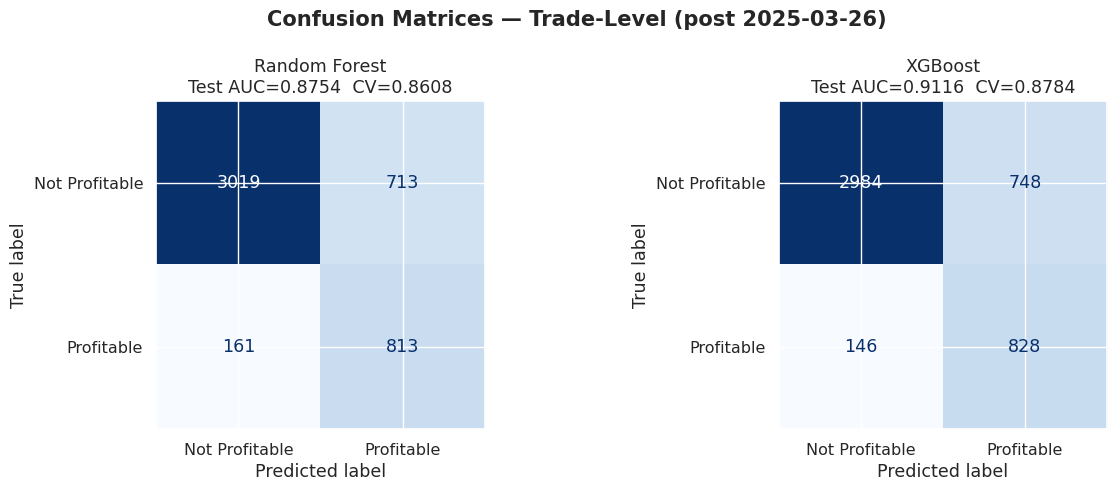

saved: model_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrices — Trade-Level (post {split_date2.date()})', fontweight='bold')
for ax, (name, m) in zip(axes, metrics2.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(yt2, m['yp']),
        display_labels=['Not Profitable','Profitable']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nTest AUC={m["roc_auc"]:.4f}  CV={cv2[name].mean():.4f}')
savefig('model_confusion_matrices.png')

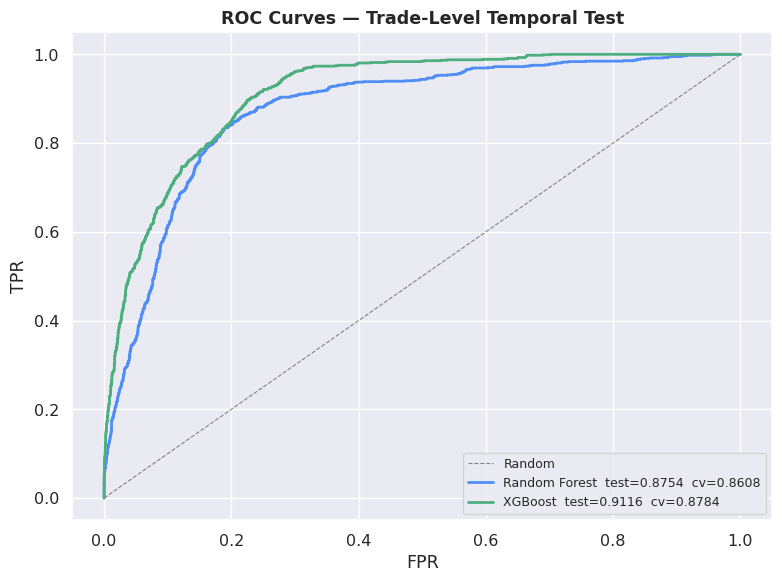

saved: model_roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', lw=.8, alpha=.5, label='Random')
for (name, m), col in zip(metrics2.items(), [BLUE, GREEN]):
    fpr, tpr, _ = roc_curve(yt2, m['ypr'])
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f'{name}  test={m["roc_auc"]:.4f}  cv={cv2[name].mean():.4f}')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Trade-Level Temporal Test', fontweight='bold')
ax.legend(fontsize=9)
savefig('model_roc_curves.png')

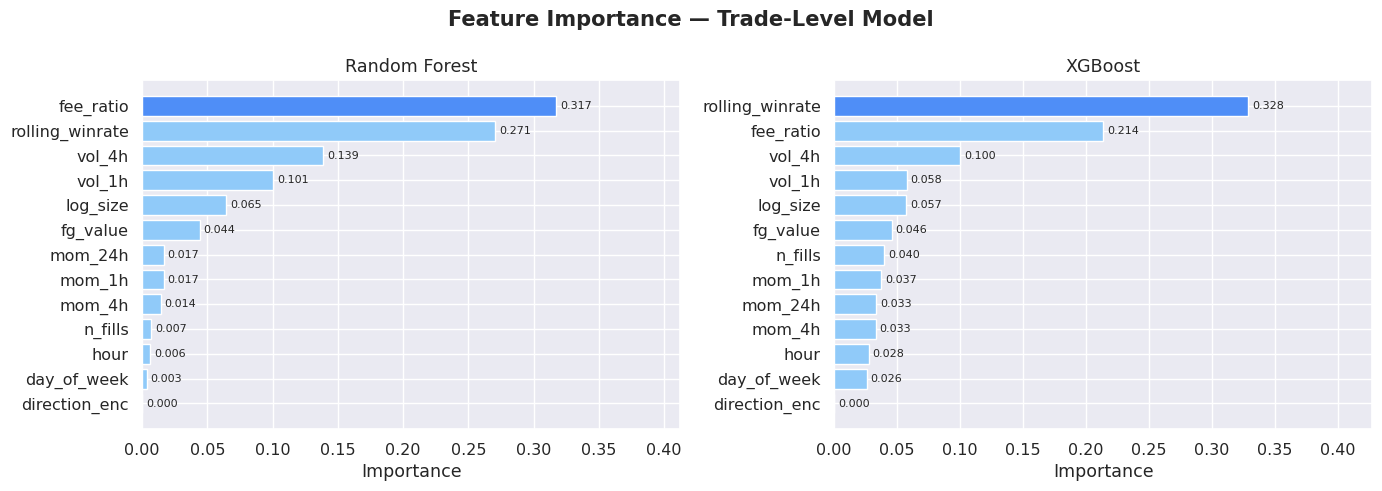

saved: model_feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — Trade-Level Model', fontweight='bold')
for ax, (name, clf) in zip(axes, [('Random Forest',rf_final),('XGBoost',xgb_final)]):
    imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
    colors = [BLUE if v==imp.max() else '#90CAF9' for v in imp]
    ax.barh(imp.index, imp.values, color=colors, edgecolor='white')
    for i, v in enumerate(imp.values): ax.text(v+.003, i, f'{v:.3f}', va='center', fontsize=8)
    ax.set_title(name); ax.set_xlabel('Importance'); ax.set_xlim(0, imp.max()*1.3)
savefig('model_feature_importance.png')

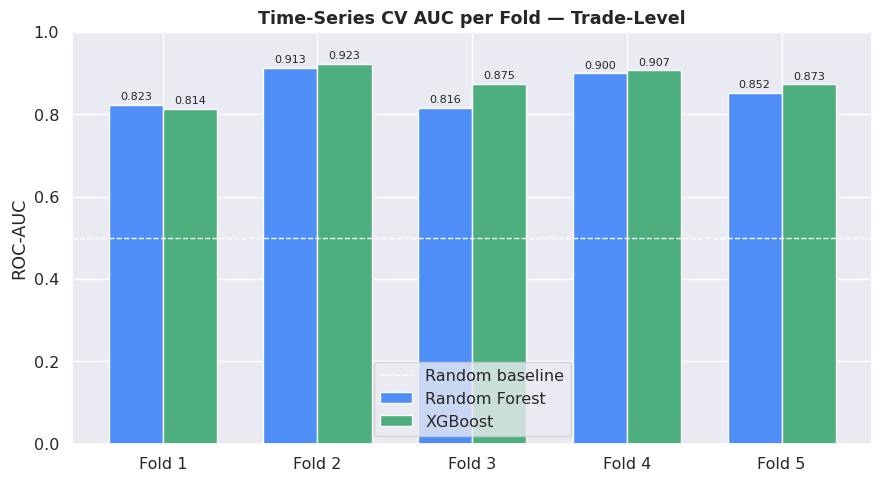

saved: model_cv_folds.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(5), .35
ax.bar(x-w/2, cv2['Random Forest'], w, color=BLUE,  edgecolor='white', label='Random Forest')
ax.bar(x+w/2, cv2['XGBoost'],       w, color=GREEN, edgecolor='white', label='XGBoost')
ax.axhline(.5, color='white', linestyle='--', lw=1, label='Random baseline')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0, 1)
ax.set_title('Time-Series CV AUC per Fold — Trade-Level', fontweight='bold')
ax.legend()
for i,(rv,xv) in enumerate(zip(cv2['Random Forest'],cv2['XGBoost'])):
    ax.text(i-w/2, rv+.012, f'{rv:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, xv+.012, f'{xv:.3f}', ha='center', fontsize=8)
savefig('model_cv_folds.png')

### Regime analysis — daily AUC on test period

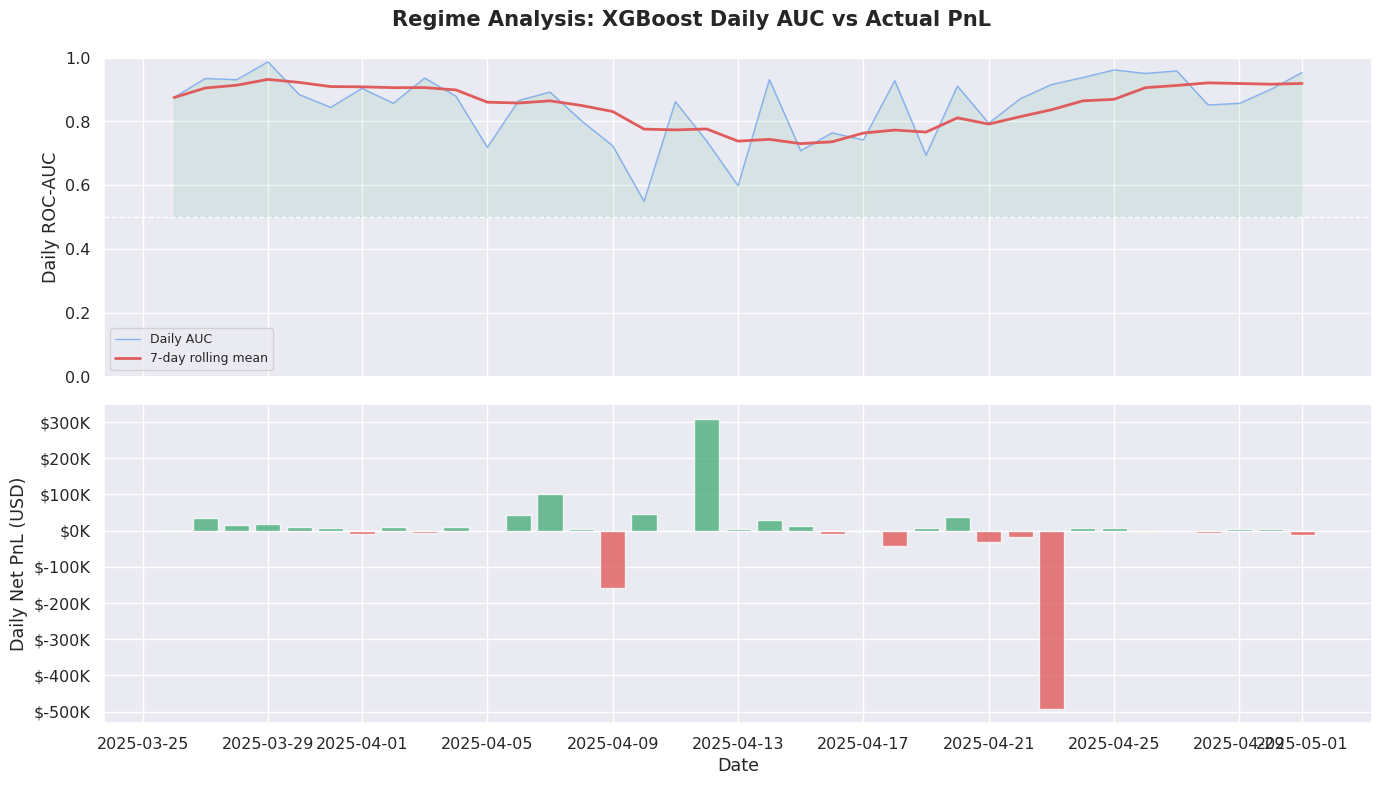

saved: regime_analysis.png


In [ ]:
xgb_final.fit(X2, y2)
tc = test2.copy(); tc['prob'] = xgb_final.predict_proba(Xt2)[:,1]
tc['date'] = tc['open_time'].dt.date

dauc = []
for date, grp in tc.groupby('date'):
    if len(grp)>=5 and grp[TARGET].nunique()==2:
        dauc.append({'date':pd.to_datetime(date),
                     'auc':roc_auc_score(grp[TARGET], grp['prob'])})

if len(dauc)>=5:
    auc_df = pd.DataFrame(dauc)
    test_pnl = (trades[trades['open_time']>=split_date2]
                .groupby(trades['open_time'].dt.date)['net_pnl'].sum().reset_index())
    test_pnl.columns = ['date','pnl']; test_pnl['date'] = pd.to_datetime(test_pnl['date'])

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('Regime Analysis: XGBoost Daily AUC vs Actual PnL', fontweight='bold')
    axes[0].plot(auc_df['date'], auc_df['auc'], color=BLUE, lw=1, alpha=.6, label='Daily AUC')
    roll = auc_df['auc'].rolling(7, min_periods=1).mean()
    axes[0].plot(auc_df['date'], roll, color=RED, lw=2, label='7-day rolling mean')
    axes[0].axhline(.5, color='white', linestyle='--', lw=1)
    axes[0].fill_between(auc_df['date'], .5, auc_df['auc'],
                         where=(auc_df['auc']<.5).values, alpha=.18, color=RED)
    axes[0].fill_between(auc_df['date'], .5, auc_df['auc'],
                         where=(auc_df['auc']>=.5).values, alpha=.12, color=GREEN)
    axes[0].set_ylabel('Daily ROC-AUC'); axes[0].set_ylim(0,1); axes[0].legend(fontsize=9)
    axes[1].bar(test_pnl['date'], test_pnl['pnl'],
                color=np.where(test_pnl['pnl']>=0, GREEN, RED), width=.8, alpha=.8)
    axes[1].axhline(0, color='white', lw=.6)
    axes[1].set_ylabel('Daily Net PnL (USD)'); axes[1].set_xlabel('Date')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    savefig('regime_analysis.png')

## 7. Threshold Analysis — XGBoost
Trading application: tune the decision threshold to balance precision (win rate) vs recall (capture rate).

In [ ]:
y_prob_xgb = xgb_final.predict_proba(Xt2)[:,1]
prec, rec, thresh = precision_recall_curve(yt2, y_prob_xgb)

rows = []
for t in np.arange(.50, .95, .05):
    yp_t = (y_prob_xgb >= t).astype(int)
    tp = ((yp_t==1)&(yt2==1)).sum()
    fp = ((yp_t==1)&(yt2==0)).sum()
    fn = ((yp_t==0)&(yt2==1)).sum()
    pr = tp/(tp+fp) if (tp+fp)>0 else 0
    rc = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*pr*rc/(pr+rc) if (pr+rc)>0 else 0
    rows.append({'Threshold':round(t,2),'Precision':round(pr,4),'Recall':round(rc,4),
                 'F1':round(f1,4),'Trades Taken':int(yp_t.sum())})

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))
thresh_df.to_csv('threshold_analysis.csv', index=False)

 Threshold  Precision  Recall     F1  Trades Taken
      0.50     0.5254  0.8501 0.6494          1576
      0.55     0.5458  0.8142 0.6535          1453
      0.60     0.5779  0.7772 0.6629          1310
      0.65     0.6107  0.7474 0.6722          1192
      0.70     0.6423  0.6858 0.6634          1040
      0.75     0.6852  0.6057 0.6431           861
      0.80     0.7387  0.5195 0.6100           685
      0.85     0.7963  0.4014 0.5338           491
      0.90     0.8492  0.2659 0.4050           305


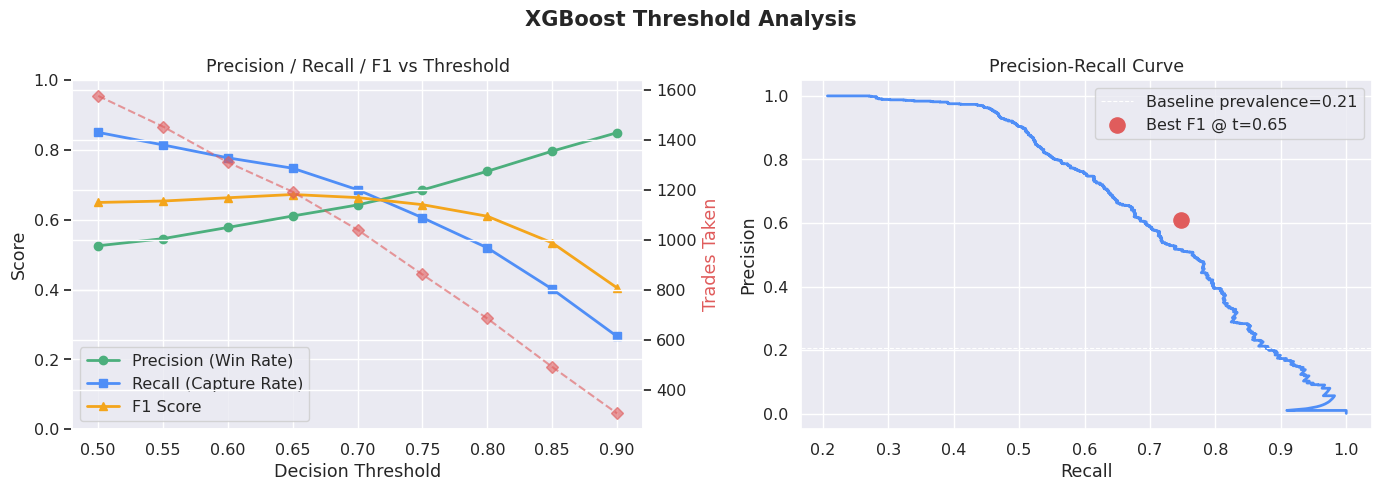

saved: threshold_tuning.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Threshold Analysis', fontweight='bold')

axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'o-', color=GREEN,
             lw=2, label='Precision (Win Rate)')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'],    's-', color=BLUE,
             lw=2, label='Recall (Capture Rate)')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'],        '^-', color=AMBER,
             lw=2, label='F1 Score')
axes[0].set_xlabel('Decision Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold'); axes[0].legend(); axes[0].set_ylim(0,1)

ax2 = axes[0].twinx()
ax2.plot(thresh_df['Threshold'], thresh_df['Trades Taken'], 'D--',
         color=RED, lw=1.5, alpha=.6, label='Trades Taken')
ax2.set_ylabel('Trades Taken', color=RED)

axes[1].plot(prec[:-1], rec[:-1], color=BLUE, lw=2)
axes[1].axhline(yt2.mean(), color='white', linestyle='--', lw=.8,
                label=f'Baseline prevalence={yt2.mean():.2f}')
best_f1_idx = thresh_df['F1'].idxmax()
axes[1].scatter(thresh_df.loc[best_f1_idx,'Recall'],
                thresh_df.loc[best_f1_idx,'Precision'],
                s=120, color=RED, zorder=5,
                label=f'Best F1 @ t={thresh_df.loc[best_f1_idx,"Threshold"]}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()
savefig('threshold_tuning.png')

## 8. Inference — Scoring a New Trade

In [ ]:
model = joblib.load('best_model.pkl')

new_trade = pd.DataFrame([{
    'log_size'       : np.log1p(5000),
    'direction_enc'  : 1,
    'fg_value'       : 72.0,
    'hour'           : 14,
    'day_of_week'    : 2,
    'mom_1h'         : 0.8,
    'mom_4h'         : 2.1,
    'mom_24h'        : 5.3,
    'vol_1h'         : 0.05,
    'vol_4h'         : 0.12,
    'fee_ratio'      : 0.0004,
    'rolling_winrate': 0.35,
    'n_fills'        : 4,
}])

prob = model.predict_proba(new_trade)[0, 1]
THRESHOLD = 0.65
decision = 'TAKE TRADE' if prob >= THRESHOLD else 'SKIP TRADE'

print(f'Profitable probability : {prob:.4f}')
print(f'Decision (t={THRESHOLD})       : {decision}')

Profitable probability : 0.5572
Decision (t=0.65)       : SKIP TRADE
